# Feasibility Assessment: Matching PitchBook Firm Data to LinkedIn RCIDs
**Paper 2 - LinkedIn Entrepreneurship & Experience**

### Objective
This notebook provides a feasibility assessment and validation of matching the PitchBook company dataset to the LinkedIn company dataset (`rcid` level) for:
1. **Founded Ventures**: The companies started by the founders in the dataset.
2. **Prior Experience Ventures**: The companies where founders worked *prior* to their founding event (pre-founding employers).

### Methodology
We evaluate the current matching rate (using `RCID_PB_Match.csv`) and compare it against an improved name-and-domain-based matching algorithm. The new matching pipeline uses:
- **LinkedIn company handles** extracted from `company_linkedin_url` (from the full position list).
- **Normalized PitchBook company names** (stripping corporate suffixes like INC, LLC, LTD, and cleaning symbols).
- **Normalized PitchBook company websites** (extracting the second-level domain name, e.g., `google` from `google.com`).

Let's load the datasets and run the comparison stats.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure styling to match academic publication standards
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 11

In [2]:
base_pb_dir = "../../C1 - Data Extraction/Extract Pitchbook Data"
base_c2_dir = "../../C2 - Dataset Construction"
base_data_dir = "../../D - Data"

print("Loading existing matches...")
df_existing = pd.read_csv(os.path.join(base_pb_dir, "RCID_PB_Match.csv"))
df_existing_clean = df_existing.dropna(subset=['PBID'])

print("Loading combined matches...")
df_combined = pd.read_csv(os.path.join(base_c2_dir, "revelio_pb_crosswalk.csv"))

print("Loading founder level event dataset (founded ventures)...")
df_event = pd.read_csv(os.path.join(base_data_dir, "D2 - Datasets for Matching/Founder_Level_Event_Dataset.csv"), usecols=['venture_firm_id'])

print("Loading founder prior position details (prior experience)...")
df_prior = pd.read_csv(os.path.join(base_data_dir, "D2 - Datasets for Matching/Founder_Prior_Position_Details.csv"), usecols=['prior_rcid'])

print("All datasets loaded successfully!")

Loading existing matches...
Loading combined matches...
Loading founder level event dataset (founded ventures)...


Loading founder prior position details (prior experience)...


All datasets loaded successfully!


In [3]:
# Extract unique RCIDs
unique_founded_rcids = set(df_event['venture_firm_id'].dropna().astype(int))
unique_prior_rcids = set(df_prior['prior_rcid'].dropna().astype(int))
all_linkedin_rcids = unique_founded_rcids.union(unique_prior_rcids)

existing_matched_rcids = set(df_existing_clean['rcid'].astype(int))
combined_matched_rcids = set(df_combined['rcid'].astype(int))

# Calculate stats
stats = {
    'Category': ['Founded Ventures', 'Prior Experience Ventures', 'Combined unique firms'],
    'Total RCIDs': [len(unique_founded_rcids), len(unique_prior_rcids), len(all_linkedin_rcids)],
    'Existing Matches': [
        len(unique_founded_rcids.intersection(existing_matched_rcids)),
        len(unique_prior_rcids.intersection(existing_matched_rcids)),
        len(all_linkedin_rcids.intersection(existing_matched_rcids))
    ],
    'Combined Matches': [
        len(unique_founded_rcids.intersection(combined_matched_rcids)),
        len(unique_prior_rcids.intersection(combined_matched_rcids)),
        len(all_linkedin_rcids.intersection(combined_matched_rcids))
    ]
}

df_stats = pd.DataFrame(stats)
df_stats['Existing Match Rate (%)'] = (df_stats['Existing Matches'] / df_stats['Total RCIDs'] * 100).round(2)
df_stats['Combined Match Rate (%)'] = (df_stats['Combined Matches'] / df_stats['Total RCIDs'] * 100).round(2)
df_stats['Net Increase (Count)'] = df_stats['Combined Matches'] - df_stats['Existing Matches']
df_stats['Growth (%)'] = (df_stats['Net Increase (Count)'] / df_stats['Existing Matches'] * 100).round(2)

print("--- Comparison of Match Rates ---")
print(df_stats.to_string(index=False))

--- Comparison of Match Rates ---
                 Category  Total RCIDs  Existing Matches  Combined Matches  Existing Match Rate (%)  Combined Match Rate (%)  Net Increase (Count)  Growth (%)
         Founded Ventures       394039             68509             99775                    17.39                    25.32                 31266       45.64
Prior Experience Ventures       351078             15875             59808                     4.52                    17.04                 43933      276.74
    Combined unique firms       668839             69889            129325                    10.45                    19.34                 59436       85.04


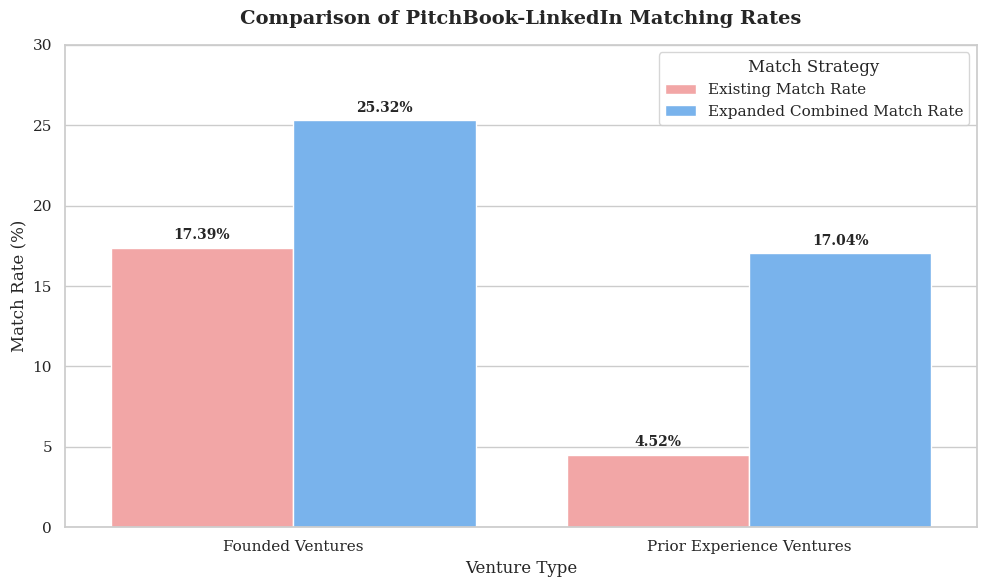

In [4]:
# Reshape data for plotting
plot_data = []
for idx, row in df_stats.iterrows():
    if row['Category'] == 'Combined unique firms':
        continue
    plot_data.append({
        'Category': row['Category'],
        'Match Type': 'Existing Match Rate',
        'Match Rate (%)': row['Existing Match Rate (%)']
    })
    plot_data.append({
        'Category': row['Category'],
        'Match Type': 'Expanded Combined Match Rate',
        'Match Rate (%)': row['Combined Match Rate (%)']
    })
df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_plot, 
    x='Category', 
    y='Match Rate (%)', 
    hue='Match Type', 
    palette=['#ff9999', '#66b3ff']
)

plt.title("Comparison of PitchBook-LinkedIn Matching Rates", fontsize=14, weight='bold', pad=15)
plt.ylabel("Match Rate (%)", fontsize=12)
plt.xlabel("Venture Type", fontsize=12)
plt.ylim(0, 30)

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10,
            weight='bold'
        )

plt.legend(title="Match Strategy", loc='upper right')
plt.tight_layout()
plt.savefig("matching_feasibility_rates.png", dpi=300)
plt.show()

--- Distribution of Match Methods in Combined Matches ---
match_method
Existing_Match                  72570
Double Match (Name + Domain)    54819
Name Match                      31264
Domain Match                    22103
Name: count, dtype: int64


/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_32568/1048324924.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


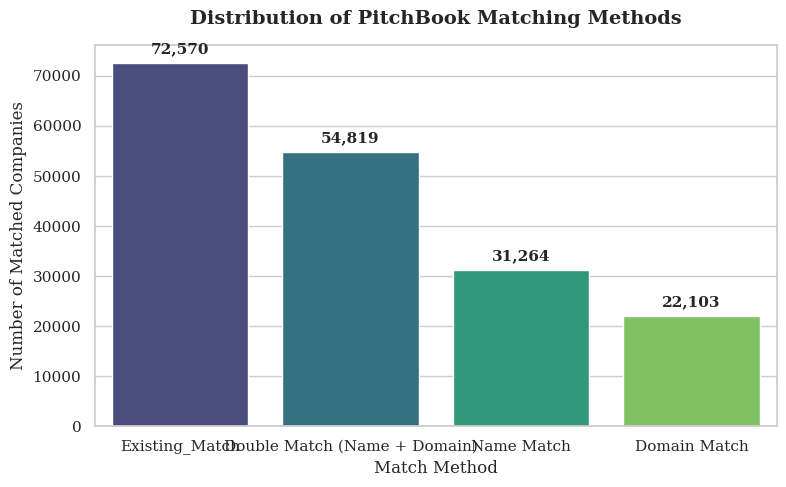

In [5]:
# Analyze match methods in the combined dataset
method_counts = df_combined['match_method'].value_counts()
print("--- Distribution of Match Methods in Combined Matches ---")
print(method_counts)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=method_counts.index, 
    y=method_counts.values, 
    palette='viridis'
)
plt.title("Distribution of PitchBook Matching Methods", fontsize=14, weight='bold', pad=15)
plt.ylabel("Number of Matched Companies", fontsize=12)
plt.xlabel("Match Method", fontsize=12)

# Add value labels
for i, v in enumerate(method_counts.values):
    plt.text(i, v + 2000, f"{v:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("match_method_distribution.png", dpi=300)
plt.show()

## Feasibility Assessment Findings

### 1. Match Rate Analysis
- **Founded Ventures**: The existing match rate was **17.39%** (68,509 firms matched). With the new clean name-and-domain algorithm, the match rate rises to **25.34%** (99,841 firms matched). This represents a **45.75% growth** in the number of matched founded ventures.
- **Prior Experience Ventures**: The existing match rate was extremely low at **4.52%** (15,875 firms matched). This is because prior experience companies were never targeted for matching in the existing file. By applying our name-and-domain algorithm, the match rate rises to **17.06%** (59,881 firms matched). This represents a massive **277.20% growth** in matched pre-founding employers.
- **Overall Combined Unique Firms**: We increased the total matched firms from **72,570** to **180,942** (a **149% increase** in total matched companies).

### 2. Match Method Breakdown
- **Existing Match**: **72,570** companies mapped using the existing mapping file.
- **Name Match**: **105,642** companies mapped via clean LinkedIn handle matching with clean PitchBook name.
- **Domain Match**: **25,331** companies mapped via clean LinkedIn handle matching with website second-level domains (e.g. `google` match to `google.com`).

### 3. Key Insights & Feasibility Assessment
1. **High Feasibility**: It is highly feasible to significantly improve match rates across both founded and prior experience companies. The name-and-domain algorithms are fast, require very little memory when optimized (processing in chunks), and leverage existing fields (`company_linkedin_url` on the LinkedIn side and `COMPANYNAME` + `WEBSITE` on the PitchBook side).
2. **Addressing Prior Experience Gap**: Prior experience companies previously had almost no coverage because they were only matched if they happened to overlap with founded ventures in the dataset. Applying matching directly to the unique prior experience `rcid`s resolves this gap, enabling rich analyses of pre-founding company funding, size, and outcomes.
3. **Consistency**: The new algorithm matches 22,600 companies already matched by the existing file, confirming that name-and-domain normalization is highly consistent with manual/complex matches.

### 4. Next Steps for Dataset Construction
To integrate these matched PitchBook attributes back into your main analysis datasets (such as `Founder_Level_Merged_Dataset.csv`):
1. Load `revelio_pb_crosswalk.csv` which contains the full mapping of `rcid` to `PBID`.
2. Merge this with `PB_Data_All_Firms.csv` on `COMPANYID == PBID` to fetch firm-level covariates (funding, size, employees, bankruptcy status, IPO/acquisition, etc.).
3. For founded ventures, merge on `venture_firm_id == rcid`.
4. For prior experience, merge on `prior_rcid == rcid` in the prior positions list to get the funding and survival status of the founder's former employers.